In [1]:
import os
import sys
from pathlib import Path

# Garantit que le package local mlops est importable depuis le notebook.
sys.path.append(os.getcwd())

from mlops.pipeline import fit_preprocessing_pipeline, save_pipeline_artifacts
from mlops.versioning import register_model, get_latest_model, promote_model
from mlops.monitoring import summarize_metrics, detect_drift, log_prediction
from mlops.retrain import retrain_with_new_data

In [2]:
import warnings

warnings.filterwarnings("ignore")

import importlib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

import train_analysis
importlib.reload(train_analysis)

from train_analysis import (
    charger_donnees,
    render_interpretation
)

from IPython.display import display, HTML
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score, cohen_kappa_score, recall_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import learning_curve

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    XGBClassifier = None
    HAS_XGBOOST = False


def prepare_titanic_features(df_raw):
    """Nettoie et encode les donnees Titanic pour la modelisation."""
    df_clean = df_raw.copy()

    if "Age" in df_clean.columns:
        df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].mean())
    if "Embarked" in df_clean.columns:
        df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode().iloc[0])

    colonnes_cat = [c for c in ["Sex", "Embarked"] if c in df_clean.columns]
    if colonnes_cat:
        df_clean = pd.get_dummies(df_clean, columns=colonnes_cat, drop_first=True, dtype=int)

    colonnes_a_supprimer = [c for c in ["PassengerId", "Name", "Ticket", "Cabin"] if c in df_clean.columns]
    if colonnes_a_supprimer:
        df_clean = df_clean.drop(columns=colonnes_a_supprimer)

    reste_cat = df_clean.select_dtypes(include=["object", "category"]).columns
    if len(reste_cat) > 0:
        df_clean = pd.get_dummies(df_clean, drop_first=True, dtype=int)

    return df_clean


def split_features_target(df_prepared, target="Survived", test_size=0.3, random_state=42):
    if target not in df_prepared.columns:
        raise ValueError(f"La colonne cible '{target}' est introuvable.")
    X = df_prepared.drop(target, axis=1)
    y = df_prepared[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    return X, y, X_train, X_test, y_train, y_test


def build_default_models(include_xgboost=True):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "SVM": SVC(probability=True),
        "Naive Bayes": GaussianNB(),
    }
    if include_xgboost and HAS_XGBOOST:
        models["XGBoost"] = XGBClassifier()
    return models


def run_scaled_grid_search(estimator, param_grid, X, y, cv=5, scoring="accuracy", n_jobs=-1):
    """GridSearchCV avec standardisation pour les modeles sensibles a l'echelle."""
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    prefixed_grid = {f"model__{k}": v for k, v in param_grid.items()}
    grid = GridSearchCV(
        pipeline,
        prefixed_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
    )
    grid.fit(X, y)
    best_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
    return grid, best_params


def plot_cv_by_model(tableau_moyennes):
    """Trace les scores moyens CV avec une couleur par modele."""
    plt.figure(figsize=(12, 5))
    positions = list(range(len(tableau_moyennes)))
    labels = tableau_moyennes["Modele"].tolist()
    scores_cv = tableau_moyennes["Score moyen CV (%)"].values

    palette = plt.cm.tab10.colors
    for i, (x, y_cv) in enumerate(zip(positions, scores_cv)):
        plt.scatter(
            x,
            y_cv,
            marker="_",
            s=1200,
            linewidths=2.5,
            color=palette[i % len(palette)]
        )

    plt.xticks(positions, labels, rotation=45, ha="right")
    plt.ylabel("Taux de succes (%)")
    plt.xlabel("Modele")
    plt.title("Comparison of Success Rate (Acc): Cross-Validation")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

<div style="text-align: center; padding: 25px; background-color: #f8f9fa; border-radius: 12px; border-left: 8px solid #2c3e50; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <h1 style="color: #2c3e50; font-family: 'Helvetica Neue', Arial, sans-serif; font-weight: bold; margin-bottom: 10px;">
        TP COMPLET : DATA SCIENCE & MACHINE LEARNING 
    </h1>
    <hr style="width: 50%; border: 1px solid #bdc3c7;">
    <h2 style="color: #223233; font-style: italic;">
        Exploration données Titanic
    </h2>
</div>

### **Partie 1 : Exploration des données**

Ce jeu de données contient des informations individuelles sur les passagers du Titanic :

- **PassengerId** : identifiant unique du passager.
- **Survived** : variable cible binaire (0 = n’a pas survécu, 1 = a survécu).
- **Pclass** : classe du billet (1 = première classe, 2 = deuxième classe, 3 = troisième classe).
- **Sex** : sexe du passager (`male` ou `female`).
- **Age** : âge du passager.
- **SibSp** : nombre de frères, sœurs, époux ou épouse voyageant avec le passager.
- **Parch** : nombre de parents ou d’enfants voyageant avec le passager.
- **Fare** : prix du billet.
- **Embarked** : port d’embarquement (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).

#### Objectif de l’analyse

L’objectif principal est de **prédire la variable `Survived`** à partir des caractéristiques disponibles (notamment `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, etc.), afin d’identifier les facteurs associés à la survie.

In [3]:
df = charger_donnees("train.csv", sep=",")

html = f"""
<p>Voici un aperçu des 5 premières lignes de la base de données :</p>
{df.head().to_html(index=False)}
"""
display(HTML(html))

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Dans l'exploration des données, nous allons nous concentrer sur les variables suivantes :
# comprendre variable : dimension , type des variables , variables cibles , lignes dupliquées , valeurs manquantes , valeurs aberrantes , corrélations entre les variables

- Dimension de la base de donnée

In [5]:
n_lignes, n_colonnes = df.shape
print(f"Dimension : {n_lignes} lignes × {n_colonnes} colonnes")


Dimension : 891 lignes × 12 colonnes


- Type de variables

In [6]:
# Type de chaque variable
types_variables = df.dtypes.reset_index()
types_variables.columns = ["Variable", "Type"]

display(types_variables)

types_uniques = types_variables["Type"].dropna().astype(str).unique()

n_numeriques = df.select_dtypes(include=["number"]).shape[1]
n_categorielles = df.select_dtypes(include=["object", "category", "bool"]).shape[1]

print(f"Variables numériques : {n_numeriques}")
print(f"Variables catégorielles : {n_categorielles}")

,Variable,Type
0,PassengerId,int64
1,Survived,int64
2,Pclass,int64
3,Name,object
4,Sex,object
5,Age,float64
6,SibSp,int64
7,Parch,int64
8,Ticket,object
9,Fare,float64


Variables numériques : 7
Variables catégorielles : 5


- Identification de la variable cible

In [7]:
counts = df["Survived"].value_counts().sort_index()
percentages = df["Survived"].value_counts(normalize=True).sort_index() * 100

resultat = pd.DataFrame({
    "Effectif": counts,
    "Pourcentage (%)": percentages.round(2)
})

print("Répartition de la variable cible qui est 'Survived' :")
display(resultat)

Répartition de la variable cible qui est 'Survived' :


,Effectif,Pourcentage (%)
Survived,,
0,549,61.62
1,342,38.38


In [8]:
# Si déséquliber ( ex: 90% de 0 et 10% de 1) => on peut faire du sur-échantillonnage ou du sous-échantillonnage ( ré-échantillonnage)
# Diminuer la taille de la classe majoritaire ou augmenter la taille de la classe minoritaire pour équilibrer les classes.

In [9]:
print(f"Ici , les données sont équilibrées : {resultat['Pourcentage (%)'].min()}% - {resultat['Pourcentage (%)'].max()}%")

Ici , les données sont équilibrées : 38.38% - 61.62%


- Vérification des lignes duppliquées

In [10]:
# Vérification des lignes dupliquées
n_duplicates = df.duplicated().sum()

print(f"Nombre de lignes dupliquées : {n_duplicates}")

if n_duplicates > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()))
else:
    print("Aucune ligne dupliquée détectée.")
    
# si il y'avait , supprimer avec drop_duplicates()

Nombre de lignes dupliquées : 0
Aucune ligne dupliquée détectée.


- Déterminer nombres de valeurs manquantes totales et pour chaque variable

In [11]:
# Nombre total de valeurs manquantes
total_valeurs_manquantes = df.isna().sum().sum()

# Nombre de valeurs manquantes par variable
valeurs_manquantes_par_variable = df.isna().sum()
pourcentage_manquants = (valeurs_manquantes_par_variable / len(df) * 100).round(2)

resume_manquants = pd.DataFrame({
    "Valeurs manquantes": valeurs_manquantes_par_variable,
    "Pourcentage (%)": pourcentage_manquants
})

resume_manquants = resume_manquants[resume_manquants["Valeurs manquantes"] > 0].sort_values(
    by="Valeurs manquantes", ascending=False
)

print(f"Nombre total de valeurs manquantes : {total_valeurs_manquantes} soit {pourcentage_manquants.sum():.2f}% des données")
display(resume_manquants)


Nombre total de valeurs manquantes : 866 soit 97.19% des données


,Valeurs manquantes,Pourcentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


- Graphique en camembert ( secteur ) des valeurs manquantes par type 

In [12]:
if not resume_manquants.empty:
    fig = px.pie(
        resume_manquants.reset_index(),
        names="index",
        values="Valeurs manquantes",
        title="Répartition des valeurs manquantes par variable",
        hole=0.2
    )
    fig.update_traces(textposition="inside", textinfo="percent+label")
    fig.show()
else:
    print("Aucune valeur manquante à afficher.")

In [13]:
html = f"""
<p>Vu que Cabin a 687 valeurs manquantes soit 77.10% des données, il est préférable de supprimer cette variable pour éviter de fausser les résultats du modèle.</p>
"""
display(HTML(html))

- Analyse univarié

Boxplot des variables continues mis à part PassengerId

In [14]:
fig_age = px.box(
    df,
    x="Age",
    title="Boxplot des Ages",
    points="outliers",
)
fig_age.show()


fig_prix = px.box(
    df,
    x="Fare",
    title="Boxplot des Fares",
    points="outliers",
)
fig_prix.show()

In [15]:
interpretation_boxplot = """
<div style="padding:14px; border-left:6px solid #2c3e50; background:#f8f9fa; border-radius:8px; color:#2c3e50;">
    <h4 style="margin-top:0; color:#2c3e50;">Interprétation du boxplot des variables continues</h4>
    <ul style="margin-bottom:0;">
        <li><b>Age</b> : distribution assez étalée, avec des valeurs extrêmes (âges très élevés) et des valeurs manquantes non visibles sur le boxplot.</li>
        <li><b>Fare</b> : distribution fortement asymétrique à droite, avec plusieurs valeurs extrêmes (billets très chers).</li>
    </ul>
    <p>L'étude univarié montre qu'on a des anomalies dans les valeurs des variables age et fare.</p>
</div>
"""
display(HTML(interpretation_boxplot))

- Analyse bivarié

Détection relation entre deux variables

Génération du Pairplot pour l'étude bivariée...


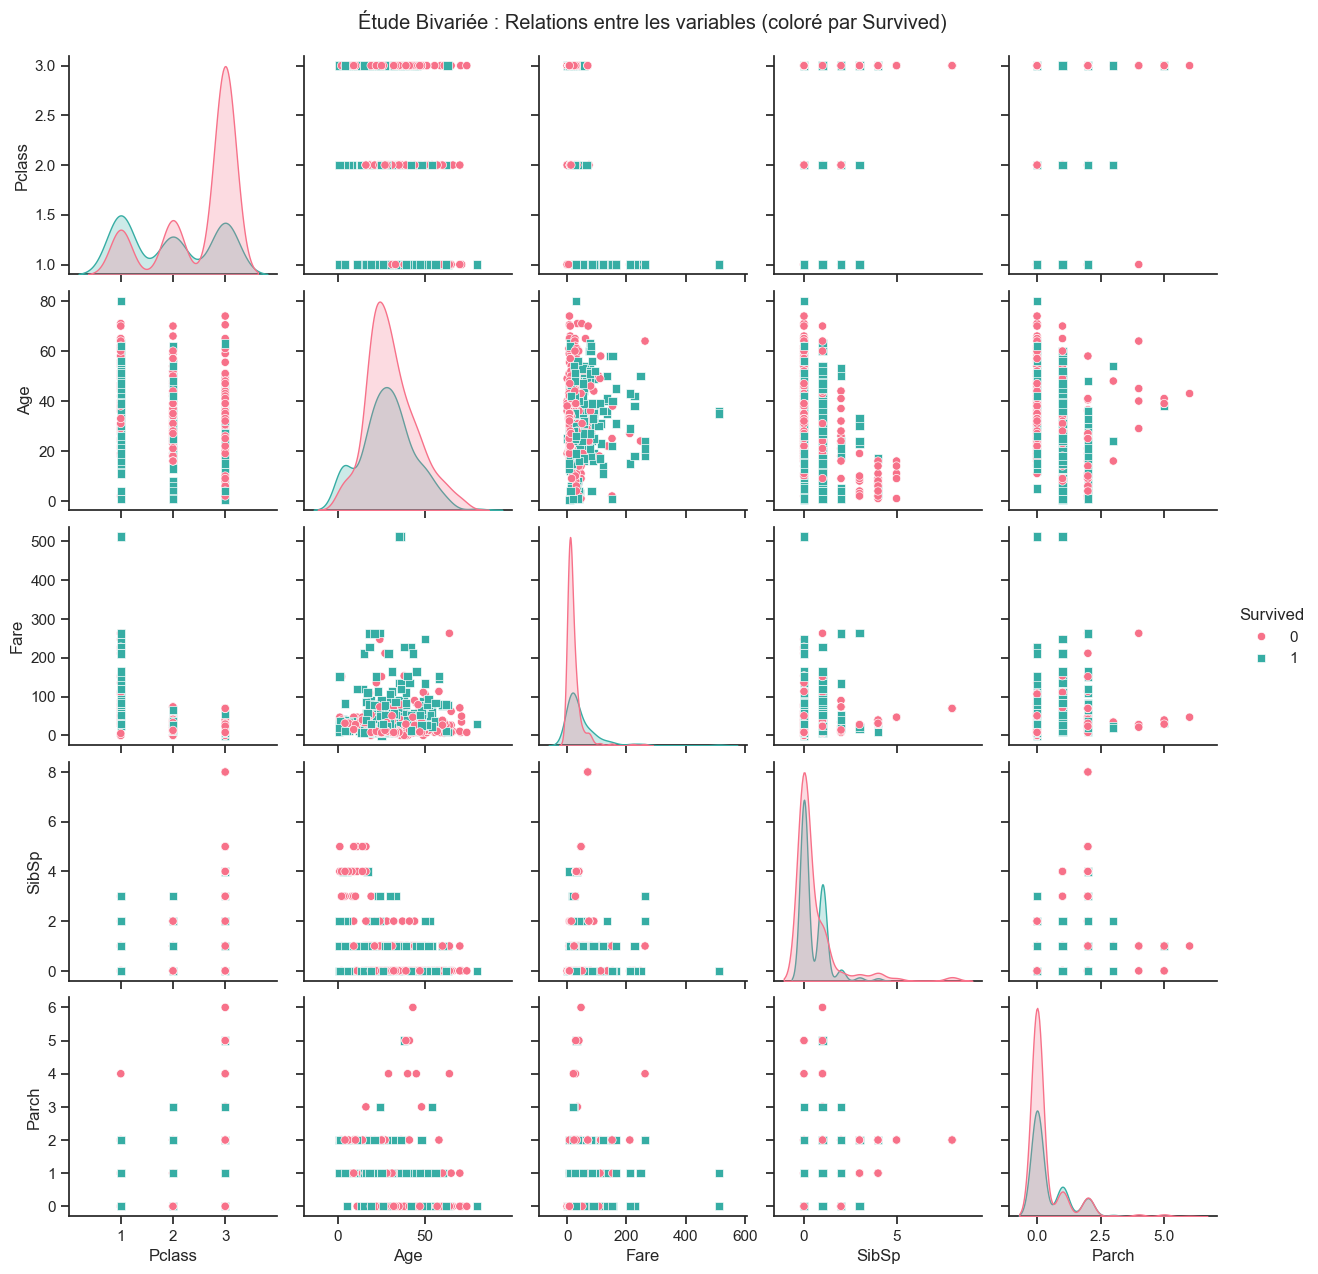

In [16]:
# Sélection des variables numériques pertinentes pour l'étude bivariée
vars_to_plot = ['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']

print("Génération du Pairplot pour l'étude bivariée...")
sns.set_theme(style="ticks")

# Création du pairplot
g = sns.pairplot(df[vars_to_plot], hue='Survived', diag_kind='kde', palette='husl', markers=["o", "s"])
g.fig.suptitle("Étude Bivariée : Relations entre les variables (coloré par Survived)", y=1.02)

plt.show()

- Matrice de colération 

In [17]:
if "df" not in globals():
    df = charger_donnees("train.csv", sep=",").copy()

corr_matrix = df.select_dtypes(include=["number"]).corr()

fig_corr = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    aspect="auto",
    title="Matrice de corrélation"
 )

fig_corr.update_layout(
    xaxis_title="Variables",
    yaxis_title="Variables",
    coloraxis_colorbar_title="Corrélation"
 )

fig_corr.show()

In [18]:
# interprétation de la matrice de corrélation
interpretation_corr = """
<div style="padding:14px; border-left:6px solid #2c3e50; background:#f8f9fa; border-radius:8px; color:#2c3e50;">
    <h4 style="margin-top:0; color:#2c3e50;">Interprétation de la matrice de corrélation</h4>
    <ul style="margin-bottom:0;">
        <li><b>Survived vs Pclass</b> : corrélation négative modérée (-0.34), indiquant que les passagers de classe inférieure avaient moins de chances de survivre.</li>
        <li><b>Survived vs Age</b> : corrélation négative faible (-0.08), suggérant que les passagers plus âgés avaient légèrement moins de chances de survivre, mais l'effet est faible.</li>
        <li><b>Survived vs Fare</b> : corrélation positive faible (0.26), indiquant que les passagers ayant payé des tarifs plus élevés avaient légèrement plus de chances de survivre, probablement en raison de leur association avec les classes supérieures.</li>
        <li><b>Survived vs SibSp</b> : corrélation négative faible (-0.16), suggérant que les passagers avec plus de frères/sœurs/époux à bord avaient légèrement moins de chances de survivre, peut-être en raison de la complexité de sauver plusieurs personnes à la fois.</li>
        <li><b>Survived vs Parch</b> : corrélation négative très faible (-0.08), indiquant que les passagers avec plus de parents/enfants à bord avaient légèrement moins de chances de survivre, mais l'effet est très faible.</li>
    </ul>
    <p>En résumé, les variables ont de très faible corrélation entre elles et n'ont pas d'impact significatif sur la survie.</p>
</div>
"""
display(HTML(interpretation_corr)) 

### **Partie 2 : Data visualisation**

### **Partie 3 : Préparation des données**

- Gestion des valeurs manquantes et Encodage des variables catégorielles

In [19]:
# Préparation centralisée
df = prepare_titanic_features(charger_donnees("train.csv", sep=","))

print(f"Préparation terminée. Colonnes restantes : {df.shape[1]}")

Préparation terminée. Colonnes restantes : 9


In [20]:
# Nombre total de valeurs manquantes
total_valeurs_manquantes = df.isna().sum().sum()

# Nombre de valeurs manquantes par variable
valeurs_manquantes_par_variable = df.isna().sum()
pourcentage_manquants = (valeurs_manquantes_par_variable / len(df) * 100).round(2)

resume_manquants = pd.DataFrame({
    "Valeurs manquantes": valeurs_manquantes_par_variable,
    "Pourcentage (%)": pourcentage_manquants
})

resume_manquants = resume_manquants[resume_manquants["Valeurs manquantes"] > 0].sort_values(
    by="Valeurs manquantes", ascending=False
)

print(f"Nombre total de valeurs manquantes : {total_valeurs_manquantes} soit {pourcentage_manquants.sum():.2f}% des données")


Nombre total de valeurs manquantes : 0 soit 0.00% des données


In [21]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [22]:
# Feature Engineering [2]
# Création de FamilySize à partir de SibSp (frères/sœurs/époux) et Parch (parents/enfants) [4, 7]
# df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

### **Partie 4 : Modélisation**

- Découpage en train et test

In [23]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

1. Régression Logistique binaire

In [24]:
glm = LogisticRegression()

# Entraînement du modèle
glm.fit(X_train, y_train)

# Évaluation du modèle
glm.score(X_test, y_test)

0.7798507462686567

In [25]:
# Prédictions sur le jeu de test
pred_glm = glm.predict(X_test)

print(pred_glm)


[0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 1 0
 1 1 1 0 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 1 0 1 1
 0 1 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 1
 0 0 0 0 1 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1
 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1 1 0 0
 1 0 0 0 1 1 0 0 0]


In [26]:
# Prédictions probabilistes
glm.predict_proba(X_test)

array([[0.85463181, 0.14536819],
       [0.30539999, 0.69460001],
       [0.79727721, 0.20272279],
       [0.77746653, 0.22253347],
       [0.96705236, 0.03294764],
       [0.92141086, 0.07858914],
       [0.51193085, 0.48806915],
       [0.73756129, 0.26243871],
       [0.90409542, 0.09590458],
       [0.86015183, 0.13984817],
       [0.30862614, 0.69137386],
       [0.50894328, 0.49105672],
       [0.72127574, 0.27872426],
       [0.03123265, 0.96876735],
       [0.03079581, 0.96920419],
       [0.63781325, 0.36218675],
       [0.36013788, 0.63986212],
       [0.89619597, 0.10380403],
       [0.86707801, 0.13292199],
       [0.90790038, 0.09209962],
       [0.04804306, 0.95195694],
       [0.8582301 , 0.1417699 ],
       [0.26911121, 0.73088879],
       [0.83881611, 0.16118389],
       [0.9190524 , 0.0809476 ],
       [0.30862614, 0.69137386],
       [0.90403279, 0.09596721],
       [0.67238276, 0.32761724],
       [0.0967963 , 0.9032037 ],
       [0.77488405, 0.22511595],
       [0.

In [27]:
def tableau_probabilites_individus(model, X_data, y_true=None):
    proba = model.predict_proba(X_data)
    pred = model.predict(X_data)

    resultat = pd.DataFrame(
        {
            "proba_classe_0": proba[:, 0],
            "proba_classe_1": proba[:, 1],
            "prediction": pred
        },
        index=X_data.index
    )

    if y_true is not None:
        resultat["valeur_reelle"] = y_true.reindex(X_data.index).values
        resultat["correct"] = (resultat["prediction"] == resultat["valeur_reelle"]).astype(int)

    return resultat


# def tableau_predictions_tous_modeles(models_dict, X_data):
#     tableau = pd.DataFrame(index=X_data.index)

#     for nom_modele, modele in models_dict.items():
#         nom_col = nom_modele.replace(" ", "_")
#         tableau[f"pred_{nom_col}"] = modele.predict(X_data)

#         if hasattr(modele, "predict_proba"):
#             tableau[f"proba1_{nom_col}"] = modele.predict_proba(X_data)[:, 1]

#     return tableau


# 1) Tableau détaillé (2 probas + prédiction) avec le modèle glm
tableau_glm = tableau_probabilites_individus(glm, X_test, y_test)
display(tableau_glm)

# 2) Tableau de l'ensemble des prédictions de tous les modèles
# tableau_ensemble = tableau_predictions_tous_modeles(models, X_test)
# display(tableau_ensemble)

,proba_classe_0,proba_classe_1,prediction,valeur_reelle,correct
220,0.854632,0.145368,0,1,0
882,0.305400,0.694600,1,0,0
545,0.797277,0.202723,0,0,1
213,0.777467,0.222533,0,0,1
116,0.967052,0.032948,0,0,1
...,...,...,...,...,...
256,0.035144,0.964856,1,1,1
41,0.202960,0.797040,1,0,0
528,0.928386,0.071614,0,0,1
80,0.877805,0.122195,0,0,1


- Matrice de confusion

In [28]:
confusion_matrix(y_test, pred_glm)

array([[145,  24],
       [ 35,  64]])

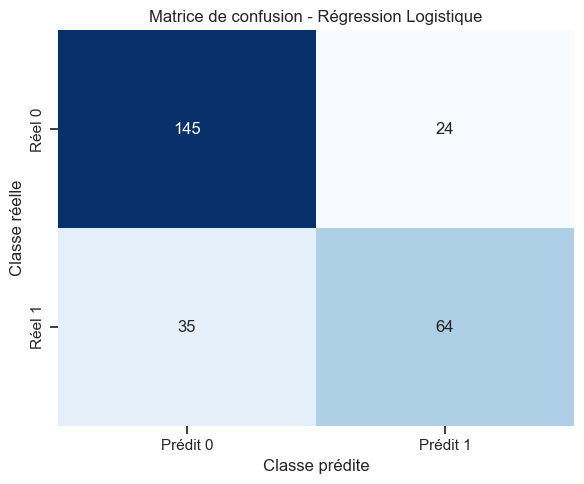

In [29]:
cm = confusion_matrix(y_test, pred_glm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Prédit 0", "Prédit 1"],
    yticklabels=["Réel 0", "Réel 1"]
)
plt.title("Matrice de confusion - Régression Logistique")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()

- Taux de succès

In [30]:
accuracy_score(y_test, pred_glm)

0.7798507462686567

In [31]:
def indicateurs_performance(model, X_test, y_test, X_train=None, y_train=None, entrainer=False):
    if entrainer and (X_train is None or y_train is None):
        raise ValueError("X_train et y_train sont requis si entrainer=True.")
    if entrainer:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    return pd.DataFrame([{
        "Modele": model.__class__.__name__,
        "Taux de succes (%)": accuracy_score(y_test, y_pred) * 100,
        "F1-score (%)": f1_score(y_test, y_pred) * 100,
        "Precision (%)": precision_score(y_test, y_pred) * 100,
        "Recall (%)": recall_score(y_test, y_pred) * 100
    }])

# Exemple d'utilisation avec ton modèle déjà entraîné :
resultats_glm = indicateurs_performance(glm, X_test, y_test)
display(resultats_glm.style.format({
    "Taux de succes (%)": "{:.1f}%",
    "F1-score (%)": "{:.1f}%",
    "Precision (%)": "{:.1f}%",
    "Recall (%)": "{:.1f}%"
}))

,Modele,Taux de succes (%),F1-score (%),Precision (%),Recall (%)
0,LogisticRegression,78.0%,68.4%,72.7%,64.6%


In [32]:
models = build_default_models(include_xgboost=True)

# Entraînement et évaluation [5]
resultats_models = []

for name, model in models.items():
    resultats = indicateurs_performance(model, X_test, y_test, X_train, y_train, entrainer=True)
    resultats["Modele"] = name
    resultats_models.append(resultats)

resultats_globaux = pd.concat(resultats_models, ignore_index=True)
display(resultats_globaux.style.format({
    "Taux de succes (%)": "{:.1f}%",
    "F1-score (%)": "{:.1f}%",
    "Precision (%)": "{:.1f}%",
    "Recall (%)": "{:.1f}%"
}))

,Modele,Taux de succes (%),F1-score (%),Precision (%),Recall (%)
0,Logistic Regression,78.4%,68.8%,73.6%,64.6%
1,KNN,66.8%,54.8%,55.1%,54.5%
2,Decision Tree,74.3%,66.3%,64.2%,68.7%
3,Random Forest,78.0%,71.5%,68.5%,74.7%
4,Gradient Boosting,80.6%,73.5%,74.2%,72.7%
5,SVM,67.2%,40.5%,61.2%,30.3%
6,Naive Bayes,77.2%,68.7%,69.8%,67.7%
7,XGBoost,79.5%,72.9%,71.2%,74.7%


### **Partie 5 : Sur Apprentissage**

- Vérifier le sur apprentissage de la Regression Logistique

In [33]:
# Vérification du sur-apprentissage de la régression logistique
pred_train_glm = glm.predict(X_train)
pred_test_glm = glm.predict(X_test)

acc_train = accuracy_score(y_train, pred_train_glm)
acc_test = accuracy_score(y_test, pred_test_glm)
f1_train = f1_score(y_train, pred_train_glm)
f1_test = f1_score(y_test, pred_test_glm)

ecart_acc = acc_train - acc_test
ecart_f1 = f1_train - f1_test

controle_surapprentissage = pd.DataFrame({
	"Jeu": ["Train", "Test", "Écart (Train - Test)"],
	"Taux de succès": [acc_train, acc_test, ecart_acc],
	"F1-score": [f1_train, f1_test, ecart_f1]
})

display(controle_surapprentissage.style.format({
	"Taux de succès": "{:.2%}",
	"F1-score": "{:.2%}"
}))

if ecart_acc > 0.05:
	print("Sur-apprentissage probable : performance nettement meilleure sur le train que sur le test.")
else:
	print("Pas de sur-apprentissage significatif : performances train/test proches.")

,Jeu,Taux de succès,F1-score
0,Train,80.90%,74.73%
1,Test,77.99%,68.45%
2,Écart (Train - Test),2.91%,6.29%


Pas de sur-apprentissage significatif : performances train/test proches.


In [34]:
# Comparaison globale des modèles (sur les 4 métriques)
metriques = ["Taux de succes (%)", "F1-score (%)", "Precision (%)", "Recall (%)"]

comparaison = resultats_globaux.copy()
comparaison["Score moyen (%)"] = comparaison[metriques].mean(axis=1)

# Ecart au meilleur modèle (sur le score moyen)
meilleur_score = comparaison["Score moyen (%)"].max()
comparaison["Ecart au meilleur (%)"] = meilleur_score - comparaison["Score moyen (%)"]

# Classement par métrique (1 = meilleur)
for m in metriques:
    comparaison[f"Rang {m}"] = comparaison[m].rank(ascending=False, method="min").astype(int)

comparaison = comparaison.sort_values("Score moyen (%)", ascending=False).reset_index(drop=True)

print("Classement des modèles (trié par score moyen) :")
display(comparaison.style.format({
    "Taux de succes (%)": "{:.1f}%",
    "F1-score (%)": "{:.1f}%",
    "Precision (%)": "{:.1f}%",
    "Recall (%)": "{:.1f}%",
    "Score moyen (%)": "{:.1f}%",
    "Ecart au meilleur (%)": "{:.1f}%",
}))

print(f"Meilleur modèle global : {comparaison.loc[0, 'Modele']} ({comparaison.loc[0, 'Score moyen (%)']:.2f}%)")

# Visualisation comparative
fig_compare = px.bar(
    comparaison.melt(
        id_vars="Modele",
        value_vars=metriques,
        var_name="Métrique",
        value_name="Valeur (%)"
    ),
    x="Modele",
    y="Valeur (%)",
    color="Métrique",
    barmode="group",
    title="Comparaison des performances de tous les modèles",
    text_auto=".1f"
)
fig_compare.update_layout(xaxis_title="Modèle", yaxis_title="Performance (%)")
fig_compare.show()

Classement des modèles (trié par score moyen) :


,Modele,Taux de succes (%),F1-score (%),Precision (%),Recall (%),Score moyen (%),Ecart au meilleur (%),Rang Taux de succes (%),Rang F1-score (%),Rang Precision (%),Rang Recall (%)
0,Gradient Boosting,80.6%,73.5%,74.2%,72.7%,75.3%,0.0%,1,1,1,3
1,XGBoost,79.5%,72.9%,71.2%,74.7%,74.6%,0.7%,2,2,3,1
2,Random Forest,78.0%,71.5%,68.5%,74.7%,73.2%,2.1%,4,3,5,1
3,Logistic Regression,78.4%,68.8%,73.6%,64.6%,71.3%,3.9%,3,4,2,6
4,Naive Bayes,77.2%,68.7%,69.8%,67.7%,70.9%,4.4%,5,5,4,5
5,Decision Tree,74.3%,66.3%,64.2%,68.7%,68.4%,6.9%,6,6,6,4
6,KNN,66.8%,54.8%,55.1%,54.5%,57.8%,17.4%,8,7,8,7
7,SVM,67.2%,40.5%,61.2%,30.3%,49.8%,25.4%,7,8,7,8


Meilleur modèle global : Gradient Boosting (75.26%)


,Modele,Taux de succes (%),Score moyen CV (%)
0,Logistic Regression,81.0%,78.9%
1,KNN,69.0%,69.1%
2,Decision Tree,74.6%,78.0%
3,Random Forest,79.5%,80.6%
4,Gradient Boosting,81.0%,82.2%
5,SVM,66.0%,67.5%
6,Naive Bayes,79.5%,77.8%
7,XGBoost,77.2%,82.3%


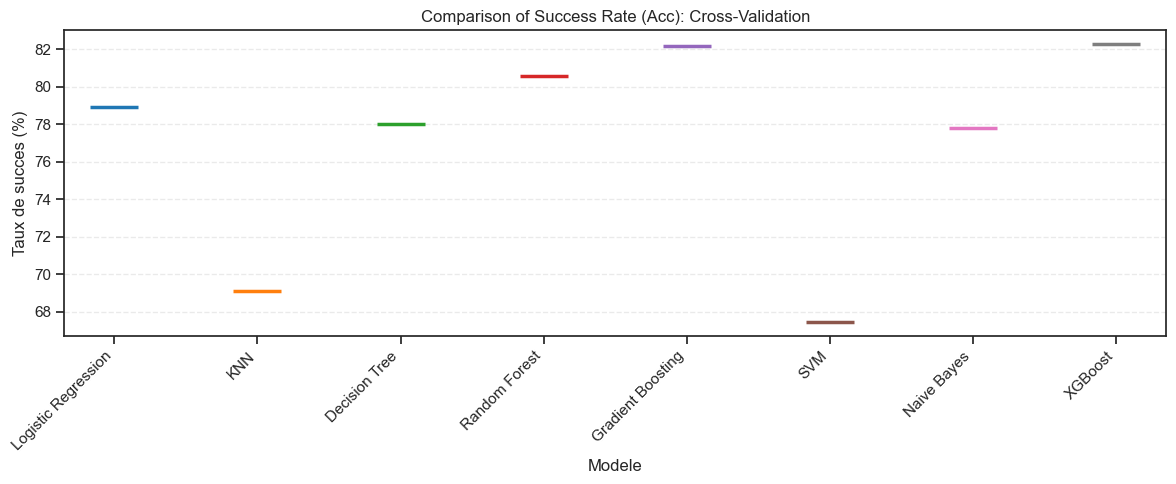

In [35]:
# Evaluation factorisee: reutilise les utilitaires globaux
if "df" not in globals() or "Survived" not in df.columns:
    df = charger_donnees("train.csv", sep=",").copy()

df_model = prepare_titanic_features(df)
X, y, X_train, X_test, y_train, y_test = split_features_target(
    df_model, target="Survived", test_size=0.3, random_state=42
)
models = build_default_models(include_xgboost=True)

if "indicateurs_performance" not in globals():
    def indicateurs_performance(model, X_test, y_test, X_train=None, y_train=None, entrainer=False):
        if entrainer and (X_train is None or y_train is None):
            raise ValueError("X_train et y_train sont requis si entrainer=True.")
        if entrainer:
            model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return pd.DataFrame([{
            "Modele": model.__class__.__name__,
            "Taux de succes (%)": accuracy_score(y_test, y_pred) * 100,
        }])

def indicateurs_performance_cv(model, X, y):
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    resume = pd.DataFrame([{
        "Modele": model.__class__.__name__,
        "Score moyen CV (%)": scores.mean() * 100,
    }])
    return resume

resultats_test = []
resultats_cv = []

for name, model in models.items():
    res_test = indicateurs_performance(
        model, X_test, y_test, X_train, y_train, entrainer=True
    )[["Modele", "Taux de succes (%)"]]
    res_test["Modele"] = name
    resultats_test.append(res_test)

    res_cv = indicateurs_performance_cv(model, X, y)
    res_cv["Modele"] = name
    resultats_cv.append(res_cv)

resultats_globaux = pd.concat(resultats_test, ignore_index=True)
resultats_globaux_cv = pd.concat(resultats_cv, ignore_index=True)

tableau_moyennes = resultats_globaux.merge(
    resultats_globaux_cv,
    on="Modele",
    how="inner"
 )[["Modele", "Taux de succes (%)", "Score moyen CV (%)"]]

display(tableau_moyennes.style.format({
    "Taux de succes (%)": "{:.1f}%",
    "Score moyen CV (%)": "{:.1f}%"
}))

# Affichage uniquement Cross-Validation 
plot_cv_by_model(tableau_moyennes)

In [36]:
X_test.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
709,3,29.699118,1,1,15.2458,1,0,0
439,2,31.000000,0,0,10.5000,1,0,1
840,3,20.000000,0,0,7.9250,1,0,1
720,2,6.000000,0,1,33.0000,0,0,1
39,3,14.000000,1,0,11.2417,0,0,0


### **Partie 6 : Grid Search CV**

- Choix du meilleur paramètre avec SVM

In [37]:
# Parametres a tester pour le SVM (avec standardisation)
params_svm = {
    "svm__C": [0.01, 1, 10, 100, 1000],
    "svm__gamma": [1, 0.1, 0.01, 0.001, 0.0001],
    "svm__kernel": ["rbf", "linear"]
}

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

grid = GridSearchCV(
    svm_pipeline,
    params_svm,
    cv=5,
)

In [38]:
# entrainement du GridSearchCV
# grid.fit(X, y)

# print(f"Meilleurs paramètres : {grid.best_params_}")
# print(f"Meilleur score CV : {grid.best_score_ * 100:.2f}%")

- Choix du meilleur paramètre avec KNN

In [39]:
# Entraînement du GridSearchCV avec k : 2 , 3 , 4 et les distances euclidienne et manhattan

params_knn = {
    "knn__n_neighbors": [2, 3, 4],
    "knn__metric": ["euclidean", "manhattan"]
}

pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

grid_knn = GridSearchCV(
    pipeline_knn,
    params_knn,
    cv=5,
)

grid_knn.fit(X, y)

print(f"Meilleurs paramètres KNN : {grid_knn.best_params_}")
print(f"Meilleur score CV KNN : {grid_knn.best_score_ * 100:.2f}%")


Meilleurs paramètres KNN : {'knn__metric': 'manhattan', 'knn__n_neighbors': 3}
Meilleur score CV KNN : 80.25%


In [40]:

# Isolation Forest : extraction de 5% d'anomalies sur la base nettoyée

df_iso = df.copy()

X_iso = df_iso.drop(columns=["Survived"], errors="ignore")

iso = IsolationForest(
	contamination=0.05, # 5% d'anomalies
	n_estimators=300 # nombre d'arbres dans la forêt
)

df_iso["anomalie_iforest"] = iso.fit_predict(X_iso)  # 1 = normal, -1 = anomalie

df_saine = df_iso[df_iso["anomalie_iforest"] == 1].drop(columns=["anomalie_iforest"]).copy()
df_anormale = df_iso[df_iso["anomalie_iforest"] == -1].drop(columns=["anomalie_iforest"]).copy()

print(f"Lignes totales : {len(df_iso)}")
print(f"Base saine     : {len(df_saine)} ({len(df_saine)/len(df_iso)*100:.2f}%)")
print(f"Base anormale  : {len(df_anormale)} ({len(df_anormale)/len(df_iso)*100:.2f}%)")

display(df_saine.head())
display(df_anormale.head())

# toujours interpréter les résultats et vérifier que les anomalies détectées sont cohérentes avec la compréhension métier du problème.

Lignes totales : 891
Base saine     : 846 (94.95%)
Base anormale  : 45 (5.05%)


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
13,0,3,39.0,1,5,31.2750,1,0,1
16,0,3,2.0,4,1,29.1250,1,1,0
25,1,3,38.0,1,5,31.3875,0,0,1
27,0,1,19.0,3,2,263.0000,1,0,1
43,1,2,3.0,1,2,41.5792,0,0,0


### **Limites des modèles de Machine Learning en terme de donnés Learning Curve**

In [41]:
# Tracer la learning curve pour XGBoost avec Plotly
train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(),
    X, 
    y, 
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 points de taille d'entraînement entre 10% et 100%
)

# Calculer les moyennes et les écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=train_sizes,
    y=train_mean,
    mode="lines+markers",
    name="Score d'entraînement",
    line=dict(color="blue"),
))

fig.add_trace(go.Scatter(
    x=np.concatenate([train_sizes, train_sizes[::-1]]),
    y=np.concatenate([train_mean - train_std, (train_mean + train_std)[::-1]]),
    fill="toself",
    fillcolor="rgba(0, 0, 255, 0.15)",
    line=dict(color="rgba(255,255,255,0)"),
    name="Écart-type entraînement",
    showlegend=True,
))

fig.add_trace(go.Scatter(
    x=train_sizes,
    y=val_mean,
    mode="lines+markers",
    name="Score de validation",
    line=dict(color="red"),
))

fig.add_trace(go.Scatter(
    x=np.concatenate([train_sizes, train_sizes[::-1]]),
    y=np.concatenate([val_mean - val_std, (val_mean + val_std)[::-1]]),
    fill="toself",
    fillcolor="rgba(255, 0, 0, 0.15)",
    line=dict(color="rgba(255,255,255,0)"),
    name="Écart-type validation",
    showlegend=True,
))

fig.update_layout(
    title="Learning Curve - XGBoost",
    xaxis_title="Taille de l'ensemble d'entraînement",
    yaxis_title="Score (Accuracy)",
    template="plotly_white",
    width=900,
    height=600,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

fig.show()

### **PARTIE 7 — ENSEMBLE LEARNING**

In [42]:
from sklearn.ensemble import VotingClassifier

# Ensemble Learning avec les 3 meilleurs modeles
voting_clf = VotingClassifier(
    estimators=[
        ("xgb", XGBClassifier()),
        ("rf", RandomForestClassifier()),
        ("gb", GradientBoostingClassifier()),
    ],
    voting="hard"
)

# Entrainement
voting_clf.fit(X_train, y_train)

# Prediction
pred_voting = voting_clf.predict(X_test)

# Evaluation
resultats_voting = pd.DataFrame([{
    "Modele": "VotingClassifier (XGBoost + Random Forest + Gradient Boosting)",
    "Taux de succes (%)": accuracy_score(y_test, pred_voting) * 100,
    "F1-score (%)": f1_score(y_test, pred_voting) * 100,
    "Precision (%)": precision_score(y_test, pred_voting) * 100,
    "Recall (%)": recall_score(y_test, pred_voting) * 100
}])

display(resultats_voting.style.format({
    "Taux de succes (%)": "{:.1f}%",
    "F1-score (%)": "{:.1f}%",
    "Precision (%)": "{:.1f}%",
    "Recall (%)": "{:.1f}%"
}))

# Matrice de confusion avec Plotly
cm_voting = confusion_matrix(y_test, pred_voting)
fig_cm_voting = px.imshow(
    cm_voting,
    text_auto=True,
    color_continuous_scale="Greens",
    labels=dict(x="Classe prédite", y="Classe réelle", color="Nombre"),
    x=["Prédit 0", "Prédit 1"],
    y=["Réel 0", "Réel 1"],
    title="Matrice de confusion - VotingClassifier"
)

fig_cm_voting.update_layout(
    template="plotly_white",
    width=700,
    height=550,
    coloraxis_showscale=False,
)

fig_cm_voting.show()

,Modele,Taux de succes (%),F1-score (%),Precision (%),Recall (%)
0,VotingClassifier (XGBoost + Random Forest + Gradient Boosting),80.2%,74.4%,80.2%,69.4%


In [43]:
import os
import joblib

# Sauvegarder tous les modèles disponibles
modeles_a_sauvegarder = {}

if "glm" in globals():
    modeles_a_sauvegarder["LogisticRegression"] = glm

if "voting_clf" in globals():
    modeles_a_sauvegarder["VotingClassifier"] = voting_clf

if "models" in globals() and isinstance(models, dict):
    for nom_modele, modele in models.items():
        modeles_a_sauvegarder[nom_modele] = modele

if not modeles_a_sauvegarder:
    raise ValueError("Aucun modèle trouvé à sauvegarder.")

features = X_train.columns.tolist() if "X_train" in globals() else []

# 1) Sauvegarde groupée dans un seul artefact
artefact = {
    "models": modeles_a_sauvegarder,
    "features": features,
}
joblib.dump(artefact, "modeles_titanic.joblib")
print("Modeles sauvegardes dans 'modeles_titanic.joblib'")

# 2) Sauvegarde individuelle par modèle
os.makedirs("modeles", exist_ok=True)
for nom_modele, modele in modeles_a_sauvegarder.items():
    nom_fichier = nom_modele.replace(" ", "_").replace("/", "_") + ".joblib"
    chemin = os.path.join("modeles", nom_fichier)
    joblib.dump({"model": modele, "features": features}, chemin)

print(f"{len(modeles_a_sauvegarder)} modeles sauvegardes individuellement dans le dossier 'modeles/'")

# (Optionnel) Test de rechargement
artefact_charge = joblib.load("modeles_titanic.joblib")
print("Modeles recharges :", list(artefact_charge["models"].keys()))

Modeles sauvegardes dans 'modeles_titanic.joblib'
10 modeles sauvegardes individuellement dans le dossier 'modeles/'
Modeles recharges : ['LogisticRegression', 'VotingClassifier', 'Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM', 'Naive Bayes', 'XGBoost']


## PARTIE 8 — MLOps

### Objectif
Comprendre comment mettre en production un modele de Machine Learning de maniere fiable, reproductible et maintenable.

### 1) Versioning du modele
- Les artefacts (pipeline + modele) sont sauvegardes sur disque.
- Chaque entrainement cree une nouvelle version horodatee dans un registre JSON.

### 2) Pipeline de donnees
- Le preprocessing est automatise via un pipeline sklearn.
- Le controle de schema assure la reproductibilite entre train et inference.

### 3) Deploiement
- API Flask exposee (`/health`, `/predict`, `/metrics`).
- Interface web minimale pour tester les predictions.

### 4) Monitoring
- Journalisation du volume, latence et classes predites.
- Detection de derive via score PSI sur les variables numeriques.

### 5) Reentrainement
- Script de reentrainement sur nouvelles donnees.
- Promotion en production seulement si la performance est suffisante.

In [44]:
# Entrainement artefacts reproductibles + versioning initial

if "voting_clf" not in globals():
    raise RuntimeError("Le modele 'voting_clf' doit etre entraine avant la Partie 8.")

if "X_train" not in globals() or "X_test" not in globals() or "y_test" not in globals():
    raise RuntimeError("X_train, X_test, y_test doivent etre disponibles.")

pipeline_artifacts = fit_preprocessing_pipeline(X_train)
pipeline_path = save_pipeline_artifacts(pipeline_artifacts, "mlops/pipeline.joblib")

X_test_t = pipeline_artifacts.pipeline.transform(X_test)
preds = voting_clf.predict(X_test_t)

metrics_v1 = {
    "accuracy": float(accuracy_score(y_test, preds)),
    "f1": float(f1_score(y_test, preds)),
}

record_v1 = register_model(
    model=voting_clf,
    pipeline_artifacts_path=str(pipeline_path),
    metrics=metrics_v1,
    features=pipeline_artifacts.features,
)

record_prod = promote_model(record_v1["version"], stage="production")

print("Version initiale enregistree:", record_v1["version"])
print("Modele promu en production:", record_prod["version"])
print("Metriques:", metrics_v1)

Version initiale enregistree: v20260417_210610
Modele promu en production: v20260417_210610
Metriques: {'accuracy': 0.4141791044776119, 'f1': 0.5857519788918206}


In [45]:
# Monitoring: resume + test derive simple

metrics_monitoring = summarize_metrics()
print("Resume monitoring:", metrics_monitoring)

# Simulation de derive en augmentant une variable numerique
X_recent = X_test.copy()
if "Fare" in X_recent.columns:
    X_recent["Fare"] = X_recent["Fare"].fillna(X_recent["Fare"].median()) * 2.0

alerts = detect_drift(reference_df=X_train, recent_df=X_recent)
print(f"Nombre d'alertes derive: {len(alerts)}")
if alerts:
    print("Exemple alerte:", alerts[0])

Resume monitoring: {'requests': 1784, 'avg_latency_ms': 0.05675485818356301, 'p95_latency_ms': 0.039163206509576054, 'class_distribution': Counter({'0': 1189, '1': 595}), 'class_ratio': {'0': 0.6664798206278026, '1': 0.3335201793721973}, 'alerts_count': 2}
Nombre d'alertes derive: 1
Exemple alerte: {'timestamp': '2026-04-17T21:06:10.327362+00:00', 'type': 'drift', 'feature': 'Fare', 'psi': 3.8451271827565603, 'threshold': 0.2}


In [46]:
# Reentrainement avec nouvelles donnees
# Adapte dataset_path si ton CSV est ailleurs.

dataset_candidates = [
    "Machine&Deep/train/train.csv",
    "Machine&Deep/train/Titanic-Dataset.csv",
    "train.csv",
]

dataset_path = None
for candidate in dataset_candidates:
    if Path(candidate).exists():
        dataset_path = candidate
        break

if dataset_path is None:
    print("Aucun dataset CSV detecte automatiquement. Mets le chemin dans dataset_path puis relance.")
else:
    retrain_result = retrain_with_new_data(dataset_path=dataset_path, target_column="Survived")
    print("Resultat reentrainement:", retrain_result)

Resultat reentrainement: {'record': {'version': 'v20260417_210610', 'created_at': '2026-04-17T21:06:10.317527+00:00', 'model_path': '/Users/fabynuur/Desktop/train/var/models/model_v20260417_210610.joblib', 'pipeline_path': 'mlops/pipeline.joblib', 'metrics': {'accuracy': 0.4141791044776119, 'f1': 0.5857519788918206}, 'features': ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S'], 'stage': 'production', 'promoted_at': '2026-04-17T21:06:10.793795+00:00'}, 'metrics': {'accuracy': 0.8100558659217877, 'f1': 0.7166666666666667}, 'promoted': True}


### Reponses aux questions

**Pourquoi le MLOps est-il important ?**
Le MLOps permet de passer d'un modele "qui marche en notebook" a un systeme fiable en production : versioning, traçabilite, automatisation, monitoring et reentrainement controle.

**Quelle difference entre ML et MLOps ?**
Le ML se concentre surtout sur la construction du modele (features, entrainement, evaluation). Le MLOps couvre tout le cycle de vie operationnel (deploiement, supervision, gouvernance, evolution continue).

**Quels risques sans monitoring ?**
Sans monitoring, on ne voit pas la derive des donnees ni la baisse de performance : predictions degradees, decisions metier incorrectes, incidents silencieux et perte de confiance dans le modele.

### Checklist de validation rapide
- Pipeline sauvegarde dans `mlops/pipeline.joblib`
- Au moins une version enregistree dans `mlops/model_registry.json`
- API Flask demarrable avec `python -m mlops.app`
- Endpoint `/predict` fonctionnel
- Alertes derive generees dans `mlops/monitoring_log.json`
- Reentrainement cree une nouvelle version du modele